In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from src.resource_estimates.gate_costs.free_fermionic import Occupation
from src.resource_estimates.gate_costs.FFFT import FFFT
from src.resource_estimates.gate_costs.interactions import ShiftedOccupationPair
from src.resource_estimates.gate_costs.hubbard_commutators import SpinSymmetricMixedControlledHappa, SpinSymmetricMixedControlledKappa
from src.resource_estimates.gate_costs.hamming_weight_phasing import HWPGate
from src.resource_estimates.gate_costs.parallelized_gate import ParallelizedResourceGate

from src.hubbard_models.split_operator_error_coefficients import (
    plaquette_second_order_split_operator_error_coefficient,
    second_order_split_operator_error_coefficient,
    cubic_second_order_split_operator_error_coefficient,
    fourth_order_suzuki_trotter_split_operator_error_coefficient,
    fourth_order_augmented_split_operator_error_coefficients,
)

from src.resource_estimates.hamiltonian_simulation import hamiltonian_simulation_cost
from src.resource_estimates.quantum_phase_estimation import adaptive_phase_estimation_resources

figsz = (7, 12)

In [2]:
tau = 1
U = 4
D = 2
x = 0.01


import math

def qubitization_t_count(eps: float, N: int) -> int:
    return math.ceil((20*np.sqrt(2) * np.pi* tau + 5*np.sqrt(2) * np.pi*U) * (2*N)**2 / eps)  

def qubitization_t_depth(eps: float, N: int) -> int:
    return math.ceil(qubitization_t_count(eps, N) / 4)  

def qubitization_t_count_3d(eps: float, N: int) -> int:
    lambd = 3*(2*N)*tau + (2*N) * U / 2
    S = 14* (2*N)
    return math.ceil(np.sqrt(2)*np.pi*lambd * S / eps)  
    

def qubitization_t_depth_3d(eps: float, N: int) -> int:
    return math.ceil(qubitization_t_count_3d(eps, N) / 4)  

def trotter_gates_2nd_order(logn: int, D: int) -> tuple[dict,...]:
    n = 2**logn
    N = n**D
    return {
        HWPGate({ShiftedOccupationPair(): N}, N): 1,
        HWPGate({FFFT(logn, D, 1):1}, n): 2,
        ParallelizedResourceGate({Occupation(): 2*N}): 1,
    },{
        HWPGate({ShiftedOccupationPair(): N}, N): 1
    }

def trotter_gates_4th_order(logn: int, D: int) -> tuple[dict,...]:
    n = 2**logn
    N = n**D
    return {
        HWPGate({ShiftedOccupationPair(): N}, N): 5,
        HWPGate({FFFT(logn, D, 1):1}, n): 10,
        ParallelizedResourceGate({Occupation(): 2*N}): 5
    },{
        HWPGate({ShiftedOccupationPair(): N}, N): 1
    }

def augmented_gates(logn: int, D: int) -> tuple[dict,...]:
    n = 2**logn
    N = n**D
    return {
        HWPGate({ShiftedOccupationPair(): N}, N): 2,
        HWPGate({FFFT(logn, D, 1):1}, n): 2,
        ParallelizedResourceGate({Occupation(): 2*N}): 1,
        HWPGate({SpinSymmetricMixedControlledHappa(): N // 2}, N //2): 2*D
    },{
        HWPGate({FFFT(logn, D, 1):1}, n): 2,
        ParallelizedResourceGate({Occupation(): 2*N}): 1,
        HWPGate({SpinSymmetricMixedControlledKappa(): N // 2}, N //2): 2*D
    }

def augmented_gates_trotter(logn: int, D: int) -> tuple[dict,...]:
    n = 2**logn
    N = n**D
    return {
        HWPGate({ShiftedOccupationPair(): N}, N): 2,
        HWPGate({FFFT(logn, D, 1):1}, n): 2,
        ParallelizedResourceGate({Occupation(): 2*N}): 1,
        HWPGate({SpinSymmetricMixedControlledHappa(): N // 2}, N //2): 2*D
    },{
        HWPGate({FFFT(logn, D, 1):1}, n): 2,
        ParallelizedResourceGate({Occupation(): 2*N}): 1,
        HWPGate({SpinSymmetricMixedControlledKappa(): N // 2}, N //2): 2*D*2
    }

gate_gens_1 = [trotter_gates_2nd_order, trotter_gates_4th_order, augmented_gates_trotter]
gate_gens_2 = [trotter_gates_2nd_order, trotter_gates_4th_order, augmented_gates]

def dict_to_t_count(dct: dict) -> int:
    tc = 0
    if "t" in dct.keys():
        tc += dct["t"] 
        
    if "tdg" in dct.keys():
        tc += dct["tdg"] 
        
    if "toffoli" in dct.keys():
        tc += 4*dct["toffoli"]
    return tc

def dict_to_t_depth(dct: dict) -> int:
    td = 0
    if "t_depth" in dct.keys():
        td += dct["t_depth"] 
        
    if "toffoli_depth" in dct.keys():
        td += 4*dct["toffoli_depth"]
    return td

In [3]:
def get_error_coefficients(n: int, D: int, U: float, tau: float, label: str, unitary_decomp: bool = True) -> dict:
    N = n**D
    match label:
        case "SO-FFFT 2":
            hopping_graph = nx.grid_graph([n]*D, periodic=True)
            if D == 2:
                return {3: plaquette_second_order_split_operator_error_coefficient(U, tau, N, hopping_graph)}
            elif D == 3:
                #print({3: second_order_split_operator_error_coefficient(U, tau, N, hopping_graph)})
                return {3: cubic_second_order_split_operator_error_coefficient(U, tau, n)}
            else:
                return {3: second_order_split_operator_error_coefficient(U, tau, N, hopping_graph)}
        case "SO-FFFT 4":
            return {5: fourth_order_suzuki_trotter_split_operator_error_coefficient(U, tau, N, 2*D)}
        case "SO-FFFT Augmented":
            return {5 + i: x for i,x in enumerate(fourth_order_augmented_split_operator_error_coefficients(U, tau, N, 2*D, unitary_decomp))}
    
for strat in ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]:
    print(get_error_coefficients(4, 3, U, tau, strat, False))

{3: np.float64(1184.0)}
{5: 1262832.8448}
{5: 1296947.2, 6: 2048.0, 7: 9327469.714285715}


# Hubbard model on the square lattice with powers of 2 side-lengths

## Hamiltonian simulation:

/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/rotation_synthesis.py:43: UserWarning: When synthesizing rotation into clifford plus T, this function does not compute the single-qubit clifford count due to arbitrary rotations.
  warnings.warn(


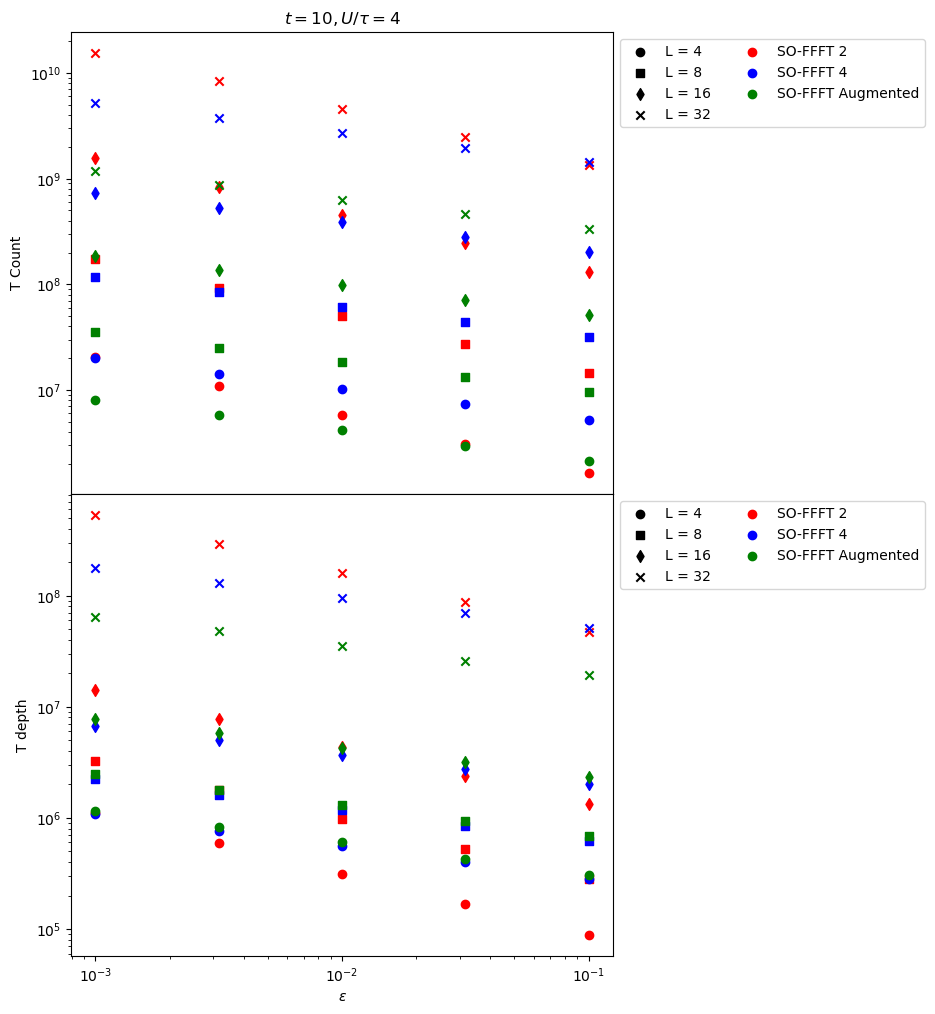

In [4]:
t = 10
logeps_list = np.linspace(-3, -1, 5)
eps_list = np.pow(10, logeps_list)
Ls = [4, 8, 16, 32]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd', 'x']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, (ax_c, ax_d) = plt.subplots(2,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_c.set_title(rf"$t = {t}, U / \tau = {U}$")
ax_d.set_xlabel(rf"$\varepsilon$")

for ax, lab in zip([ax_c, ax_d], ["T Count", "T depth"]):
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
        
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(lab)
    
for gate_gen, color, comp_strat in zip(gate_gens_1, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [hamiltonian_simulation_cost(
            t, 
            e, 
            t_gates, 
            outer_gates=u_gates, 
            error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, True),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for e in eps_list
               ]
        ys_c = [dict_to_t_count(d) for d in dcts]
        ax_c.scatter(eps_list, ys_c, marker = marker_style, c = color)
        ys_d = [dict_to_t_depth(d) for d in dcts]
        ax_d.scatter(eps_list, ys_d, marker = marker_style, c = color)

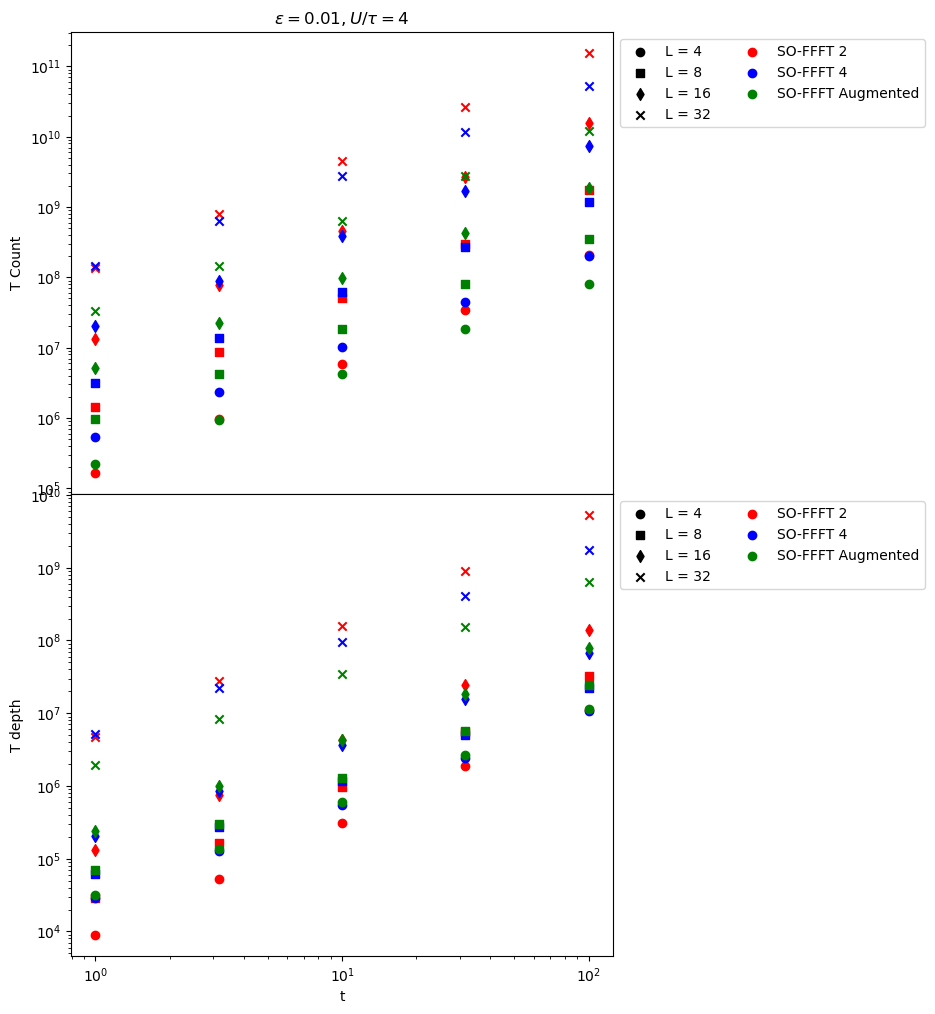

In [5]:
logts = np.linspace(0, 2, 5)
ts = np.pow(10, logts)
eps = 0.01
Ls = [4, 8, 16, 32]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd', 'x']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, (ax_c, ax_d) = plt.subplots(2,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_c.set_title(rf"$\varepsilon = {eps}, U / \tau = {U}$")
ax_d.set_xlabel(rf"t")

for ax, lab in zip([ax_c, ax_d], ["T Count", "T depth"]):
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
        
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(lab)
    
for gate_gen, color, comp_strat in zip(gate_gens_1, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [hamiltonian_simulation_cost(
            t, 
            eps, 
            t_gates, 
            outer_gates=u_gates, 
            error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, True),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for t in ts
               ]
        ys_c = [dict_to_t_count(d) for d in dcts]
        ax_c.scatter(ts, ys_c, marker = marker_style, c = color)
        ys_d = [dict_to_t_depth(d) for d in dcts]
        ax_d.scatter(ts, ys_d, marker = marker_style, c = color)

## Quantum Phase Estimation

SO-FFFT 2
L: 4
T count: [80552599972, 13562458706, 2242397015, 368643824, 60201870]
T Depth: [4343240200, 731158942, 120865280, 19865996, 3243905]
L: 8
T count: [77590481836, 12920131176, 2141506146, 358632106, 58847035]
T Depth: [1418449076, 239239935, 40233186, 6827246, 1142089]
L: 16
T count: [80123086408, 13398483910, 2231553696, 369988307, 61051148]
T Depth: [700684448, 121344535, 21002376, 3635122, 630848]
L: 32


/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/quantum_phase_estimation.py:144: UserWarning: minimize failed to converge with msg:
ABNORMAL: 
  warnings.warn(


T count: [92117835059, 15583704829, 2594098698, 429955462, 70857144]
T Depth: [3168818497, 541975143, 91604686, 15453188, 2602926]
SO-FFFT 4
L: 4
T count: [63507797080, 14258903370, 3143836490, 700475620, 155429340]
T Depth: [3424217636, 768704438, 169452354, 37749184, 8374950]
L: 8
T count: [59792567863, 13448251585, 3015789402, 674070511, 147691988]
T Depth: [1095752427, 249018737, 56485584, 12787250, 2853220]
L: 16
T count: [61580418171, 13898018241, 3086821752, 692481064, 154896720]
T Depth: [542174823, 125867801, 29049382, 6740268, 1565190]
L: 32
T count: [71588120287, 16149799920, 3585058544, 804209900, 179898532]
T Depth: [2462606171, 561660585, 126591488, 28789660, 6542188]
SO-FFFT Augmented
L: 4
T count: [25086647608, 5629244376, 1259139664, 276166230, 61265766]
T Depth: [3637198126, 814985606, 182000228, 39825131, 8815577]
L: 8
T count: [17472911142, 3938394726, 885416022, 195670704, 43766728]
T Depth: [1199877720, 272663526, 61849861, 13839784, 3129730]
L: 16
T count: [15262

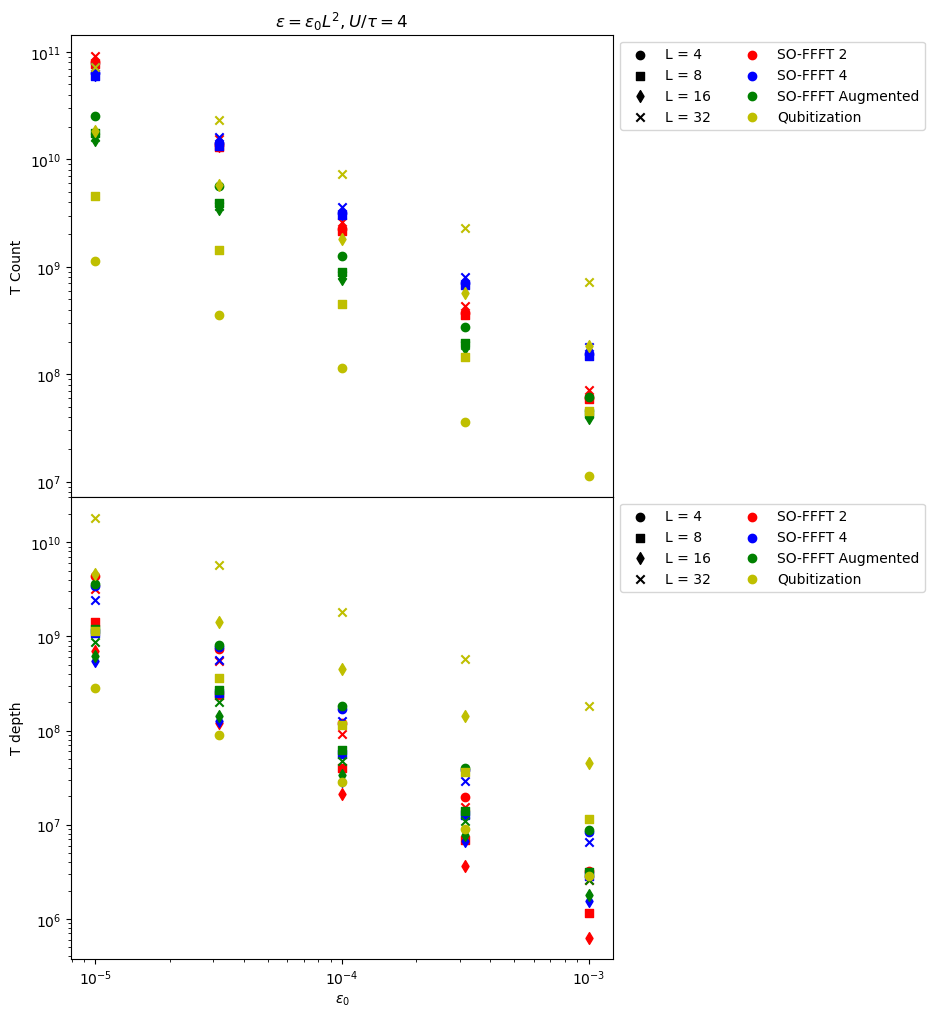

In [6]:
logeps_list = np.linspace(-5, -3, 5)
eps_list = np.pow(10, logeps_list)
Ls = [4, 8, 16, 32]

colors = ['r', 'b', 'g' ,"y"]
marker_styles = ['o', 's', 'd', 'x']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented", "Qubitization"]

fig, (ax_c, ax_d) = plt.subplots(2,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_c.set_title(rf"$\varepsilon = \varepsilon_0L^2, U / \tau = {U}$")
ax_d.set_xlabel(rf"$\varepsilon_0$")

for ax, lab in zip([ax_c, ax_d], ["T Count", "T depth"]):
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
        
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(lab)
    
for gate_gen, color, comp_strat in zip(gate_gens_2 + ["_"], colors, comp_strats):
    print(comp_strat)
    for L, marker_style in zip(Ls, marker_styles):
        print("L:", L)
        if comp_strat == "Qubitization":
            ys_c = [qubitization_t_count(e * L**2, L**2) for e in eps_list]
            ys_d = [qubitization_t_depth(e * L**2, L**2) for e in eps_list]
            ax_c.scatter(eps_list, ys_c, marker = marker_style, c = color)
            ax_d.scatter(eps_list, ys_d, marker = marker_style, c = color)
        else:
            t_gates, u_gates = gate_gen(int(np.log2(L)), D)
            dcts = [adaptive_phase_estimation_resources(
                e * L**2, 
                t_gates, 
                unitary_gates=u_gates, 
                unitary_error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, False),
                x=x,
                synthesize_rotation_with="RUS"
            )
                for e in eps_list
                   ]
            ys_c = [dict_to_t_count(d) for d in dcts]
            ax_c.scatter(eps_list, ys_c, marker = marker_style, c = color)
            ys_d = [dict_to_t_depth(d) for d in dcts]
            ax_d.scatter(eps_list, ys_d, marker = marker_style, c = color)
        print("T count:", ys_c)
        print("T Depth:", ys_d)

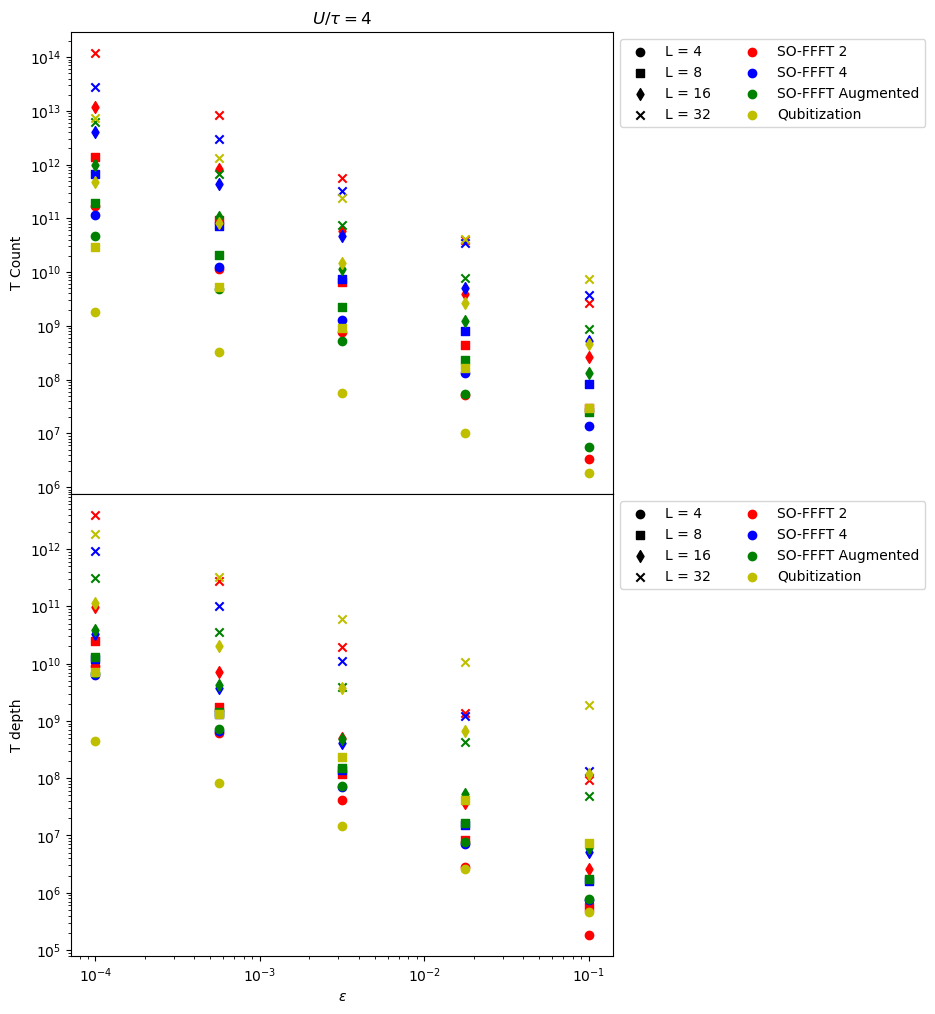

In [7]:
logeps_list = np.linspace(-4, -1, 5)
eps_list = np.pow(10, logeps_list)
Ls = [4, 8, 16, 32]

colors = ['r', 'b', 'g', 'y']
marker_styles = ['o', 's', 'd', 'x']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented", "Qubitization"]

fig, (ax_c, ax_d) = plt.subplots(2,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_c.set_title(rf"$U / \tau = {U}$")
ax_d.set_xlabel(rf"$\varepsilon$")

for ax, lab in zip([ax_c, ax_d], ["T Count", "T depth"]):
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
        
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(lab)

for gate_gen, color, comp_strat in zip(gate_gens_2 + ["_"], colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        if comp_strat == "Qubitization":
            ys_c = [qubitization_t_count(e, L**2) for e in eps_list]
            ys_d = [qubitization_t_depth(e, L**2) for e in eps_list]
            ax_c.scatter(eps_list, ys_c, marker = marker_style, c = color)
            ax_d.scatter(eps_list, ys_d, marker = marker_style, c = color)
        else:
            t_gates, u_gates = gate_gen(int(np.log2(L)), D)
            dcts = [adaptive_phase_estimation_resources(
                e, 
                t_gates, 
                unitary_gates=u_gates, 
                unitary_error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, False),
                x=x,
                synthesize_rotation_with="RUS"
            )
                for e in eps_list
                   ]
            ys_c = [dict_to_t_count(d) for d in dcts]
            ax_c.scatter(eps_list, ys_c, marker = marker_style, c = color)
            ys_d = [dict_to_t_depth(d) for d in dcts]
            ax_d.scatter(eps_list, ys_d, marker = marker_style, c = color)

# The Hubbard model on the cubic lattice:

In [8]:
tau = 1
U = 4
D = 3
x = 0.01

## Hamiltonian simulation:

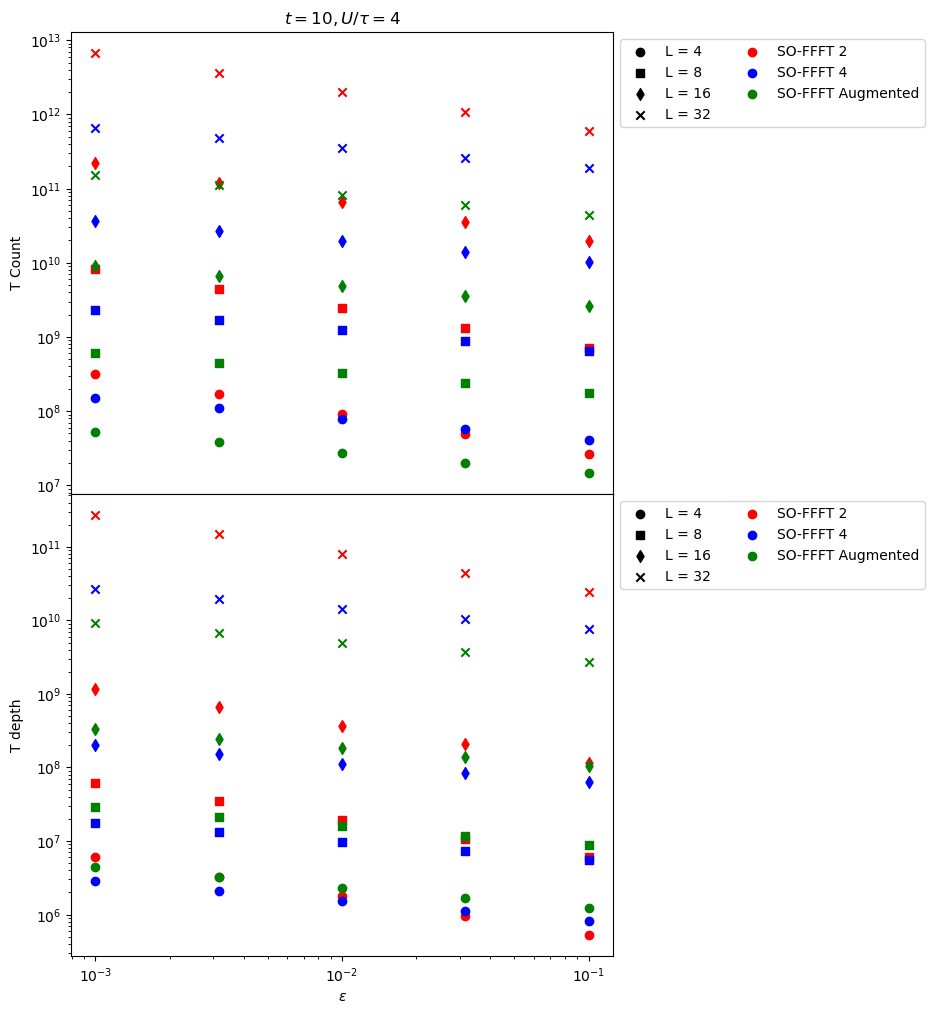

In [9]:
t = 10
logeps_list = np.linspace(-3, -1, 5)
eps_list = np.pow(10, logeps_list)
Ls = [4, 8, 16, 32]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd', 'x']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, (ax_c, ax_d) = plt.subplots(2,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_c.set_title(rf"$t = {t}, U / \tau = {U}$")
ax_d.set_xlabel(rf"$\varepsilon$")

for ax, lab in zip([ax_c, ax_d], ["T Count", "T depth"]):
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
        
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(lab)

for gate_gen, color, comp_strat in zip(gate_gens_1, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [hamiltonian_simulation_cost(
            t, 
            e, 
            t_gates, 
            outer_gates=u_gates, 
            error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, True),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for e in eps_list
               ]
        ys_c = [dict_to_t_count(d) for d in dcts]
        ax_c.scatter(eps_list, ys_c, marker = marker_style, c = color)
        ys_d = [dict_to_t_depth(d) for d in dcts]
        ax_d.scatter(eps_list, ys_d, marker = marker_style, c = color)

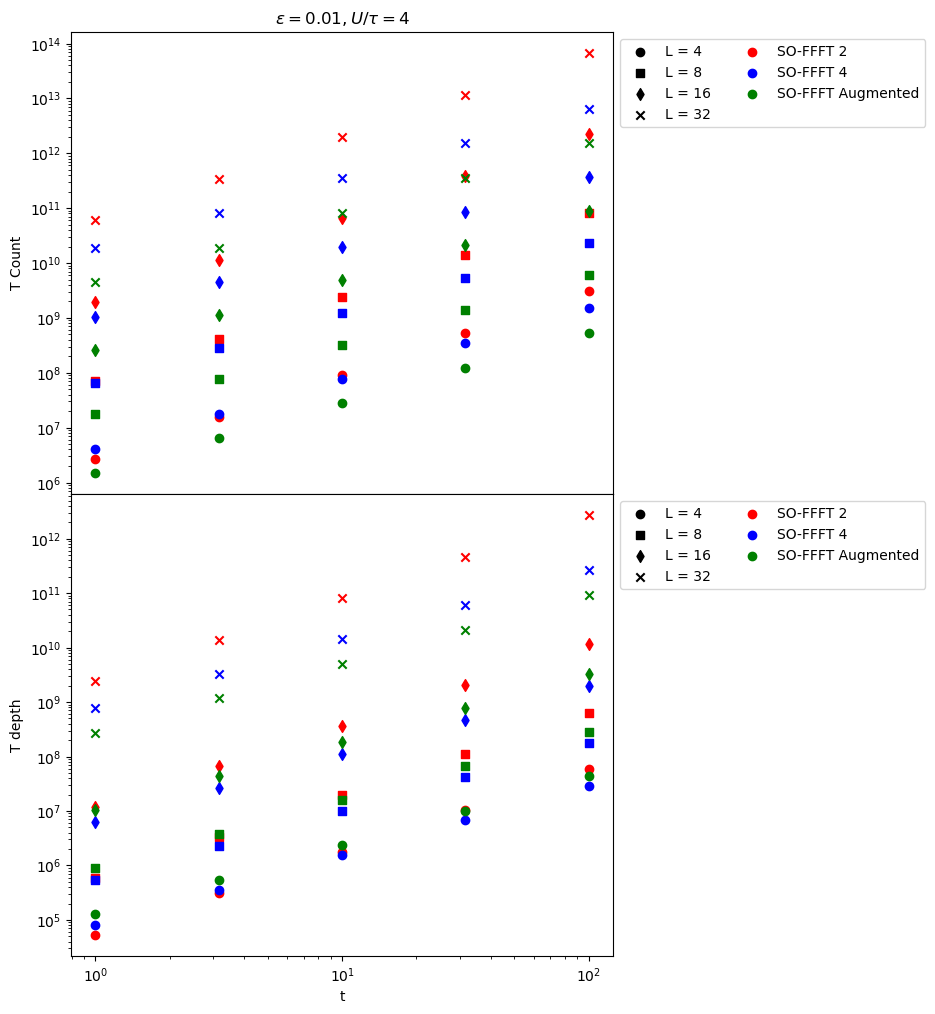

In [10]:
logts = np.linspace(0, 2, 5)
ts = np.pow(10, logts)
eps = 0.01
Ls = [4, 8, 16, 32]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd', 'x']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, (ax_c, ax_d) = plt.subplots(2,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_c.set_title(rf"$\varepsilon = {eps}, U / \tau = {U}$")
ax_d.set_xlabel(rf"t")

for ax, lab in zip([ax_c, ax_d], ["T Count", "T depth"]):
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
        
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(lab)

for gate_gen, color, comp_strat in zip(gate_gens_1, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [hamiltonian_simulation_cost(
            t, 
            eps, 
            t_gates, 
            outer_gates=u_gates, 
            error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, True),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for t in ts
               ]
        ys_c = [dict_to_t_count(d) for d in dcts]
        ax_c.scatter(ts, ys_c, marker = marker_style, c = color)
        ys_d = [dict_to_t_depth(d) for d in dcts]
        ax_d.scatter(ts, ys_d, marker = marker_style, c = color)

## Quantum Phase Estimation

SO-FFFT 2
L: 4
T count: [141690729162, 23590118832, 3909322954, 654555270, 107374484]
T Depth: [2623161648, 442674172, 74489509, 12645803, 2116212]
L: 8
T count: [142968458726, 24188846296, 4027008460, 667334234, 110060384]
T Depth: [1067967969, 187534751, 32825442, 5749170, 1010734]
L: 16
T count: [155062002612, 26042074604, 4358693352, 736903432, 122990901]
T Depth: [885301324, 157111008, 27914614, 4993392, 914216]
L: 32
T count: [190590250476, 31931755844, 5334134068, 901102768, 153518504]
T Depth: [7802197209, 1315974974, 221650022, 37859800, 6608002]
SO-FFFT 4
L: 4
T count: [77777370720, 17491025328, 3865325849, 863055930, 191982548]
T Depth: [1443631378, 328223536, 73650983, 16673205, 3767043]
L: 8
T count: [78235206492, 17640265424, 3967017056, 876641898, 195955590]
T Depth: [589741246, 138092168, 32335476, 7548948, 1772550]
L: 16
T count: [84874611690, 19223443772, 4291081044, 969352968, 218588500]
T Depth: [489812595, 115979237, 27474344, 6546490, 1574812]
L: 32
T count: [1042

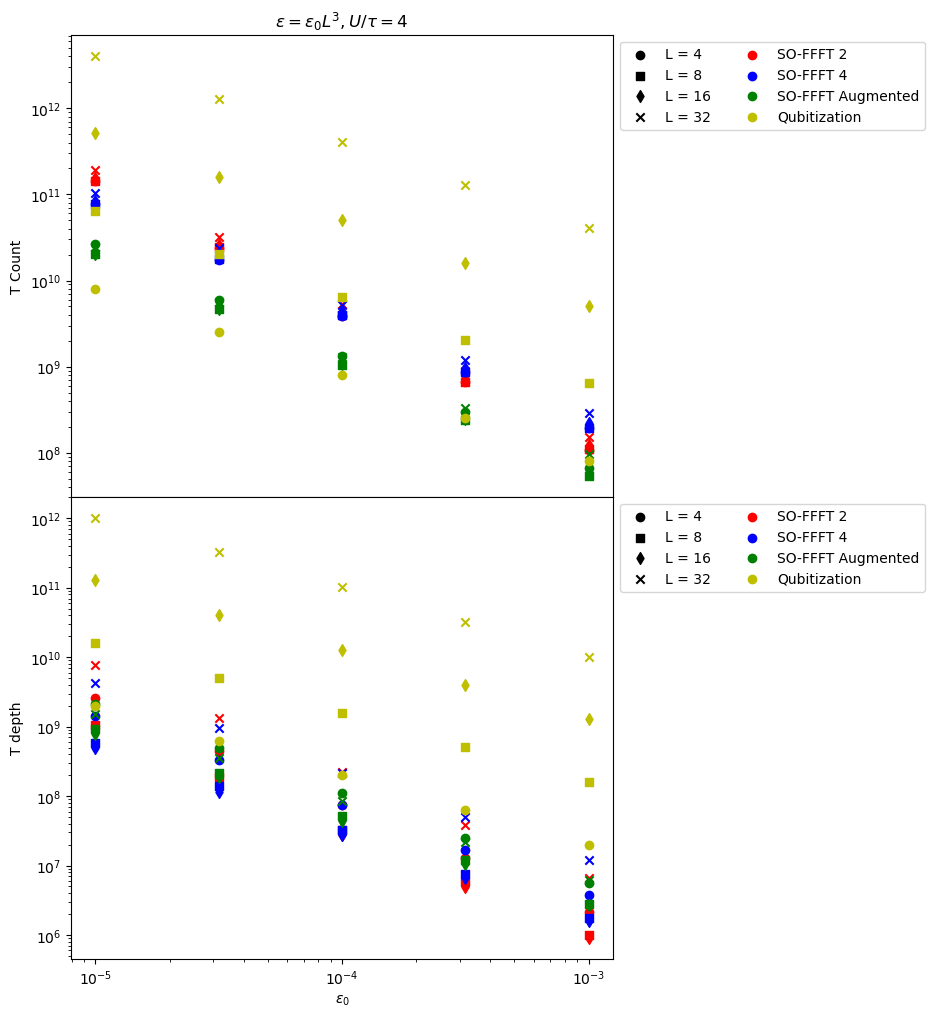

In [11]:
logeps_list = np.linspace(-5, -3, 5)
eps_list = np.pow(10, logeps_list)
Ls = [4, 8, 16, 32]

colors = ['r', 'b', 'g', 'y']
marker_styles = ['o', 's', 'd', 'x']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented", "Qubitization"]

fig, (ax_c, ax_d) = plt.subplots(2,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_c.set_title(rf"$\varepsilon = \varepsilon_0L^{D}, U / \tau = {U}$")
ax_d.set_xlabel(rf"$\varepsilon_0$")

for ax, lab in zip([ax_c, ax_d], ["T Count", "T depth"]):
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
        
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(lab)

for gate_gen, color, comp_strat in zip(gate_gens_2 + ["_"], colors, comp_strats):
    print(comp_strat)
    for L, marker_style in zip(Ls, marker_styles):
        print("L:", L)
        if comp_strat == "Qubitization":
            ys_c = [qubitization_t_count_3d(e * L**3, L**3) for e in eps_list]
            ys_d = [qubitization_t_depth_3d(e * L**3, L**3) for e in eps_list]
            ax_c.scatter(eps_list, ys_c, marker = marker_style, c = color)
            ax_d.scatter(eps_list, ys_d, marker = marker_style, c = color)
        else:
            t_gates, u_gates = gate_gen(int(np.log2(L)), D)
            dcts = [adaptive_phase_estimation_resources(
                e * L**D, 
                t_gates, 
                unitary_gates=u_gates, 
                unitary_error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, False),
                x=x,
                synthesize_rotation_with="RUS"
            )
                for e in eps_list
                   ]
            ys_c = [dict_to_t_count(d) for d in dcts]
            ax_c.scatter(eps_list, ys_c, marker = marker_style, c = color)
            ys_d = [dict_to_t_depth(d) for d in dcts]
            ax_d.scatter(eps_list, ys_d, marker = marker_style, c = color)
        print("T count:", ys_c)
        print("T Depth:", ys_d)

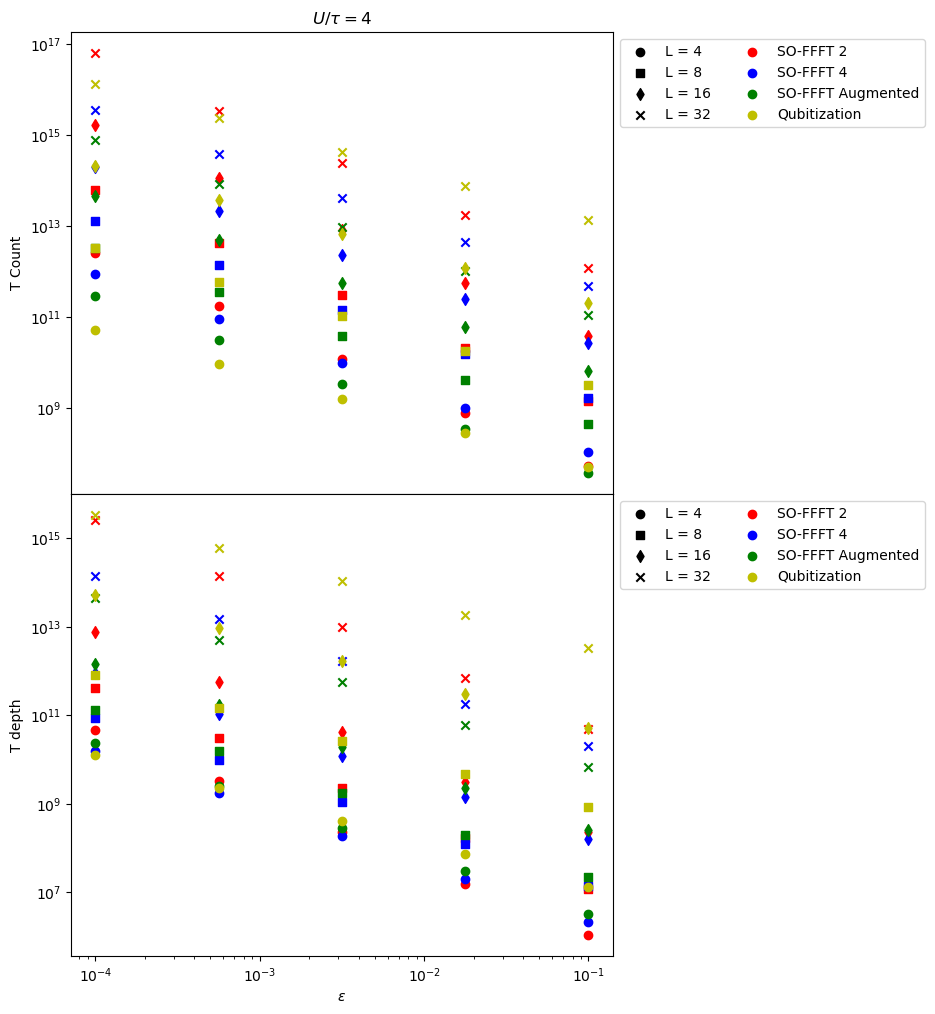

In [12]:
logeps_list = np.linspace(-4, -1, 5)
eps_list = np.pow(10, logeps_list)
Ls = [4, 8, 16, 32]

colors = ['r', 'b', 'g', 'y']
marker_styles = ['o', 's', 'd' ,'x']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented", "Qubitization"]

fig, (ax_c, ax_d) = plt.subplots(2,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_c.set_title(rf"$U / \tau = {U}$")
ax_d.set_xlabel(rf"$\varepsilon$")

for ax, lab in zip([ax_c, ax_d], ["T Count", "T depth"]):
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
        
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(lab)

for gate_gen, color, comp_strat in zip(gate_gens_2 + ["_"], colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        if comp_strat == "Qubitization":
            ys_c = [qubitization_t_count_3d(e, L**3) for e in eps_list]
            ys_d = [qubitization_t_depth_3d(e, L**3) for e in eps_list]
            ax_c.scatter(eps_list, ys_c, marker = marker_style, c = color)
            ax_d.scatter(eps_list, ys_d, marker = marker_style, c = color)
        else:
            t_gates, u_gates = gate_gen(int(np.log2(L)), D)
            dcts = [adaptive_phase_estimation_resources(
                e, 
                t_gates, 
                unitary_gates=u_gates, 
                unitary_error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, False),
                x=x,
                synthesize_rotation_with="RUS"
            )
                for e in eps_list
                   ]
            ys_c = [dict_to_t_count(d) for d in dcts]
            ax_c.scatter(eps_list, ys_c, marker = marker_style, c = color)
            ys_d = [dict_to_t_depth(d) for d in dcts]
            ax_d.scatter(eps_list, ys_d, marker = marker_style, c = color)